In [2]:
import pandas as pd
import seaborn as sns

In [3]:
df = sns.load_dataset('titanic')
df = df[['survived', 'pclass', 'age', 'fare', 'sibsp', 'parch', 'embarked', 'who']]

In [5]:
X = df[['pclass', 'age', 'fare', 'sibsp', 'parch', 'embarked', 'who']]
y = df['survived']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42, stratify=y
)

In [7]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [8]:
# Define the categorical logic as its own mini-pipeline
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
# Put it all together in the ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('cat', cat_transformer, ['embarked', 'who']),
    ('num', SimpleImputer(strategy='median'), ['age', 'fare', 'pclass', 'sibsp', 'parch'])
], remainder='passthrough')
model = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('gradient', GradientBoostingClassifier(n_estimators=1000, learning_rate=0.01, max_depth=3))
])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('gradient', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [13]:
# THE TRANSLATION (Fixes the 'male' error)
# We use everything in the pipeline EXCEPT the last step to prep the data
X_test_prepped = model[:-1].transform(X_test) 
X_train_prepped = model[:-1].transform(X_train)

Checking data: X_train_prepped shape: (712, 7)
Checking data: X_test_prepped shape: (179, 7)
--- Training model with Learning Rate: 1.0 ---
Captured 3000 stages for LR 1.0
--- Training model with Learning Rate: 0.1 ---
Captured 3000 stages for LR 0.1
--- Training model with Learning Rate: 0.01 ---
Captured 3000 stages for LR 0.01


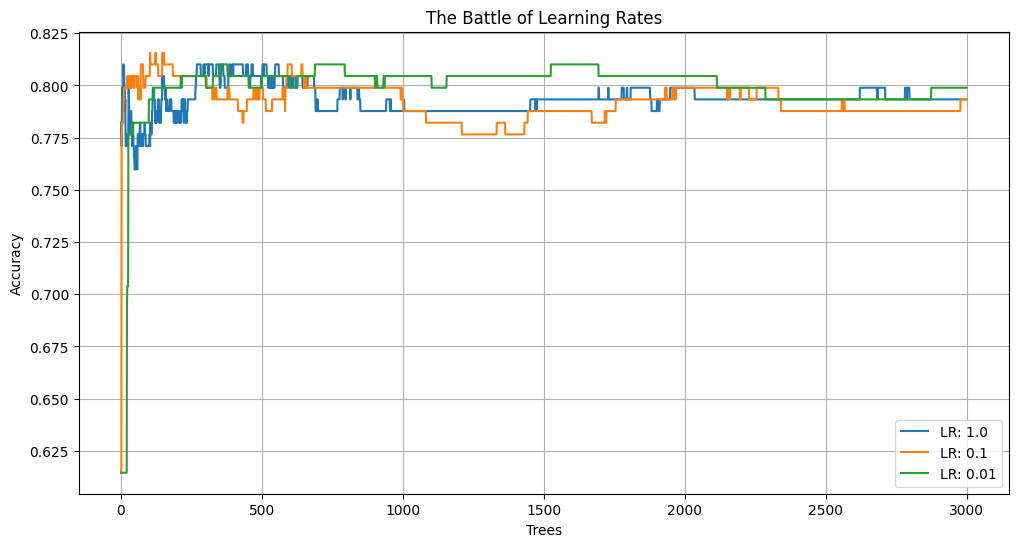

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# 1. Verification Check
print(f"Checking data: X_train_prepped shape: {X_train_prepped.shape}")
print(f"Checking data: X_test_prepped shape: {X_test_prepped.shape}")

results = {}
learning_rates = [1.0, 0.1, 0.01]

for lr in learning_rates:
    print(f"--- Training model with Learning Rate: {lr} ---")
    
    # Create and fit
    clf = GradientBoostingClassifier(n_estimators=3000, learning_rate=lr, max_depth=3, random_state=42)
    clf.fit(X_train_prepped, y_train)
    
    staged_scores = []
    
    # Capture the scores
    for i, pred in enumerate(clf.staged_predict(X_test_prepped)):
        score = accuracy_score(y_test, pred)
        staged_scores.append(score)
    
    print(f"Captured {len(staged_scores)} stages for LR {lr}")
    results[lr] = staged_scores

# 2. Plotting (Only if we actually have data)
if any(len(s) > 0 for s in results.values()):
    plt.figure(figsize=(12, 6))
    for lr, scores in results.items():
        if len(scores) > 0:
            plt.plot(range(1, len(scores) + 1), scores, label=f'LR: {lr}')
    
    plt.xlabel('Trees')
    plt.ylabel('Accuracy')
    plt.title('The Battle of Learning Rates')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("CRITICAL ERROR: No scores were captured. Check your X_test_prepped variable.")

In [32]:
print(f"Rows in training data: {X_train_prepped.shape[0]}")
print(f"Number of trees in model: {len(model.estimators_)}")

Rows in training data: 712
Number of trees in model: 1000
